<a href="https://colab.research.google.com/github/CagatayEsen/BUSI-Segmentation/blob/main/BUSI_Segmentasyon_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BUSI Meme Ultrason Segmentasyonu — Tek Dosya (Colab)

**Klasik (oracle + otomatik) vs Derin Öğrenme (UNet++ / EfficientNet-B4)**, aynı hold-out test setinde, sızıntısız.

## Çalıştırma sırası
1. **Bölüm 0–1:** Drive'ı bağla, BUSI'yi indir. (Kaggle token gerekir — aşağıda.)
2. **Bölüm 2–3:** Veri setini hazırla + split. **Buradaki özet tabloyu onayla.**
3. **Bölüm 4–5:** Klasik yöntemler (CPU, hızlı).
4. **Bölüm 6–7:** Derin öğrenme eğitimi (GPU, uzun — fold-bazlı resume var, oturum koparsa kaldığı yerden devam eder).
5. **Bölüm 8–9:** Sızıntısız değerlendirme + karşılaştırma/istatistik/figürler.
6. **Bölüm 10:** (Opsiyonel) ablasyon / dış doğrulama.

> **Önemli:** Eğitime (Bölüm 7) geçmeden önce Bölüm 3'teki split özetini gözden geçir.
> Tüm sonuçlar `BUSI_Project/outputs` altına ve checkpoint'ler `BUSI_Project/checkpoints` altına Drive'a kaydedilir.


In [ ]:
# Bölüm 0 — Kurulum
!pip -q install segmentation-models-pytorch albumentations timm kaggle

import os, random, math, json, glob, warnings, shutil
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, cv2
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

# ---- Ayarlar ----
SEED        = 42
IMG_SIZE    = 256          # T4 dostu; klasik + DL + metrik hep bu çözünürlükte
N_FOLDS     = 5
TEST_FRAC   = 0.20
INCLUDE_NORMAL = True       # normal (tümörsüz) görüntüler dahil
ENCODER     = "efficientnet-b4"
BATCH_SIZE  = 16
NUM_EPOCHS  = 120
PATIENCE    = 20
LR_INIT     = 3e-4

BASE = "/content/drive/MyDrive/BUSI_Project"
RAW  = f"{BASE}/raw"
PROC = f"{BASE}/processed"
SPL  = f"{BASE}/splits"
CKPT = f"{BASE}/checkpoints"
OUT  = f"{BASE}/outputs"
for d in [BASE, RAW, PROC, f"{PROC}/images", f"{PROC}/masks", SPL, CKPT, OUT]:
    os.makedirs(d, exist_ok=True)

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
set_seed()
print("Ayarlar hazır. BASE =", BASE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00
Mounted at /content/drive
Ayarlar hazır. BASE = /content/drive/MyDrive/BUSI_Project


## Bölüm 1 — BUSI'yi indir
Kaggle token gerekir: kaggle.com → Settings → API → **Create New Token** → inen `kaggle.json` dosyasını Colab'a (`/content` altına) yükle.

In [ ]:
# Böl. 1 (güncellenmiş) — Kaggle'dan indir
!pip -q install -U kaggle
import os, glob, shutil
src_root = f"{RAW}/Dataset_BUSI_with_GT"
if os.path.isdir(src_root) and len(glob.glob(f"{src_root}/*/*.png")) > 0:
    print("Ham veri zaten Drive'da, indirme atlandı.")
else:
    cand = [p for p in ["/content/kaggle.json",
                        "/content/drive/MyDrive/kaggle.json"] if os.path.exists(p)]
    if not cand:
        raise SystemExit("kaggle.json bulunamadı — önce files.upload() ile yükle.")
    os.makedirs("/root/.kaggle", exist_ok=True)
    shutil.copy(cand[0], "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
    print("kaggle.json:", cand[0])
    !kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset -p "{RAW}" --unzip
    print("Bitti:", glob.glob(f"{RAW}/*"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 2.9 MB/s eta 0:00:00
Ham veri zaten Drive'da, indirme atlandı.


In [ ]:
from google.colab import files
files.upload()   # kaggle.json'u seç

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aatayesen","key":"b74134bf0e1a4888f6123b0ddfe3a3b2"}'}

## Bölüm 2 — Veri setini hazırla
Her görüntü için **çoklu maskeler OR ile birleştirilir**, tek binary maskeye indirilir; görüntü+maske eşlenip `processed/` altına yazılır. Normal görüntüler boş maskeyle dahil edilir.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 31.1 MB/s eta 0:00:00


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

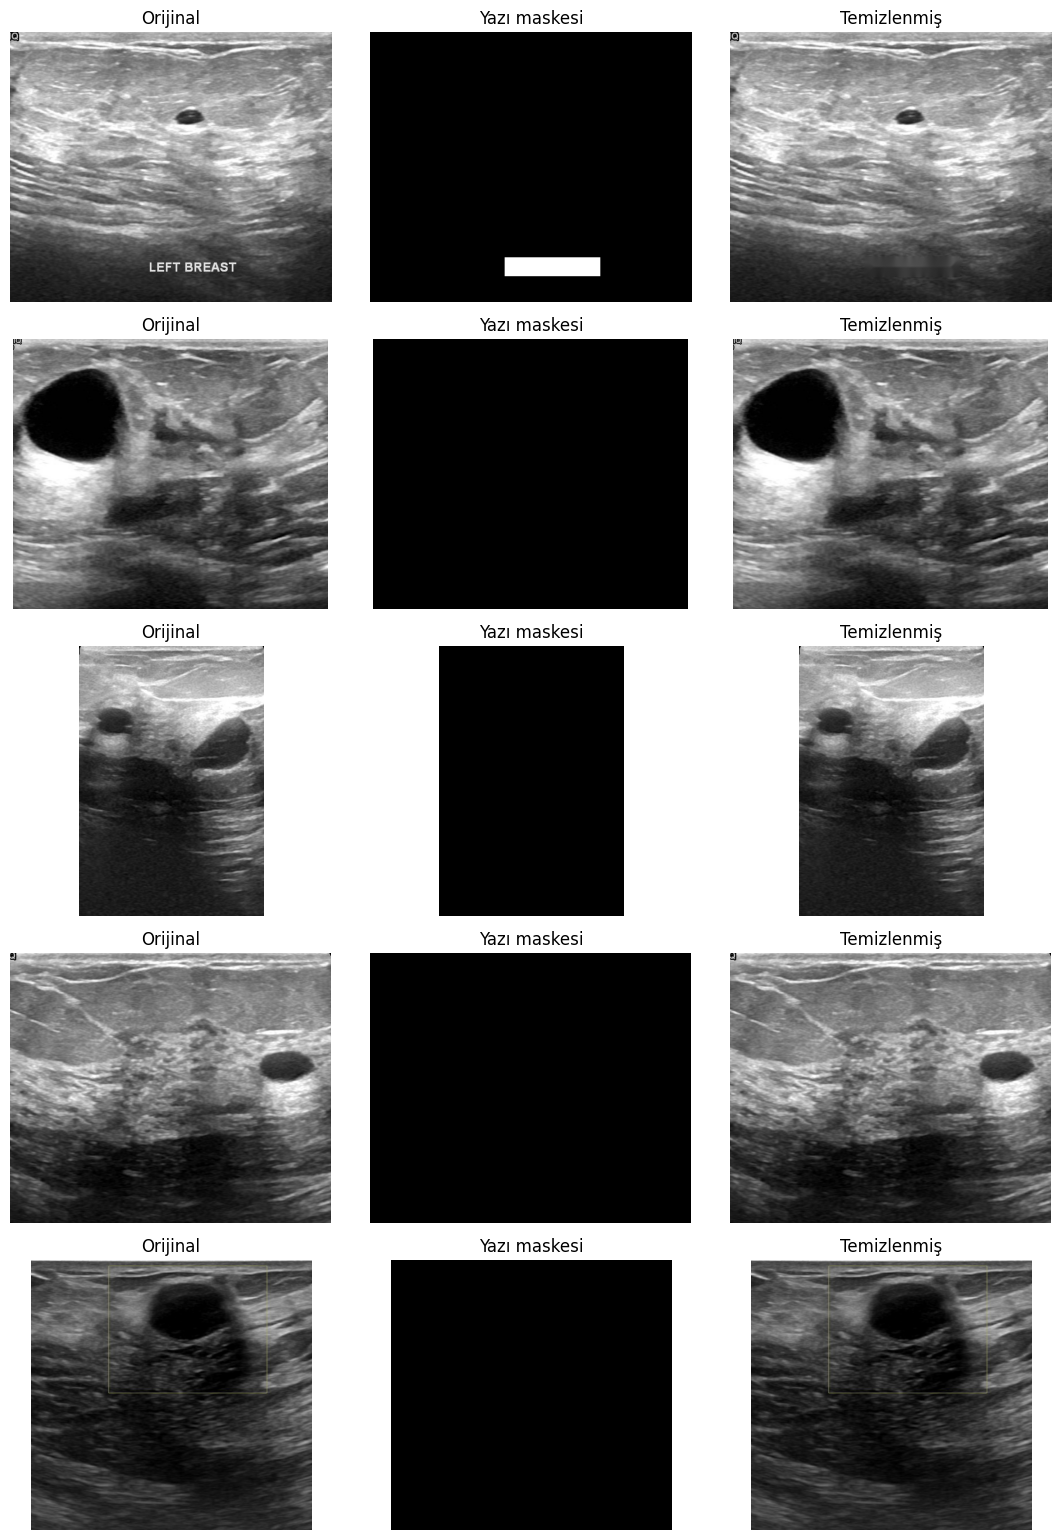

In [ ]:
# Yazı temizliği — OCR tabanlı (sağlam)
!pip -q install easyocr
import easyocr, matplotlib.pyplot as plt
reader = easyocr.Reader(['en'], gpu=True)

def remove_text(img_bgr, conf_thr=0.3, pad=3):
    res = reader.readtext(img_bgr, detail=1, paragraph=False)
    m = np.zeros(img_bgr.shape[:2], np.uint8)
    for box, txt, conf in res:
        if conf < conf_thr:
            continue
        pts = np.array(box).astype(np.int32)
        cv2.fillConvexPoly(m, pts, 1)
    if m.sum() == 0:
        return img_bgr, m
    m = cv2.dilate(m, np.ones((2*pad+1, 2*pad+1), np.uint8), 1)
    return cv2.inpaint(img_bgr, (m*255).astype(np.uint8), 3, cv2.INPAINT_TELEA), m

samples = [s for s in sorted(glob.glob(f"{RAW}/Dataset_BUSI_with_GT/*/*.png"))
           if "_mask" not in os.path.basename(s)][:5]
fig, ax = plt.subplots(len(samples), 3, figsize=(11, 3.1*len(samples)))
for r, sp in enumerate(samples):
    bgr = cv2.imread(sp); cleaned, m = remove_text(bgr)
    ax[r,0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); ax[r,0].set_title("Orijinal")
    ax[r,1].imshow(m, cmap="gray"); ax[r,1].set_title("Yazı maskesi")
    ax[r,2].imshow(cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB)); ax[r,2].set_title("Temizlenmiş")
    for c in range(3): ax[r,c].axis("off")
plt.tight_layout(); plt.show()

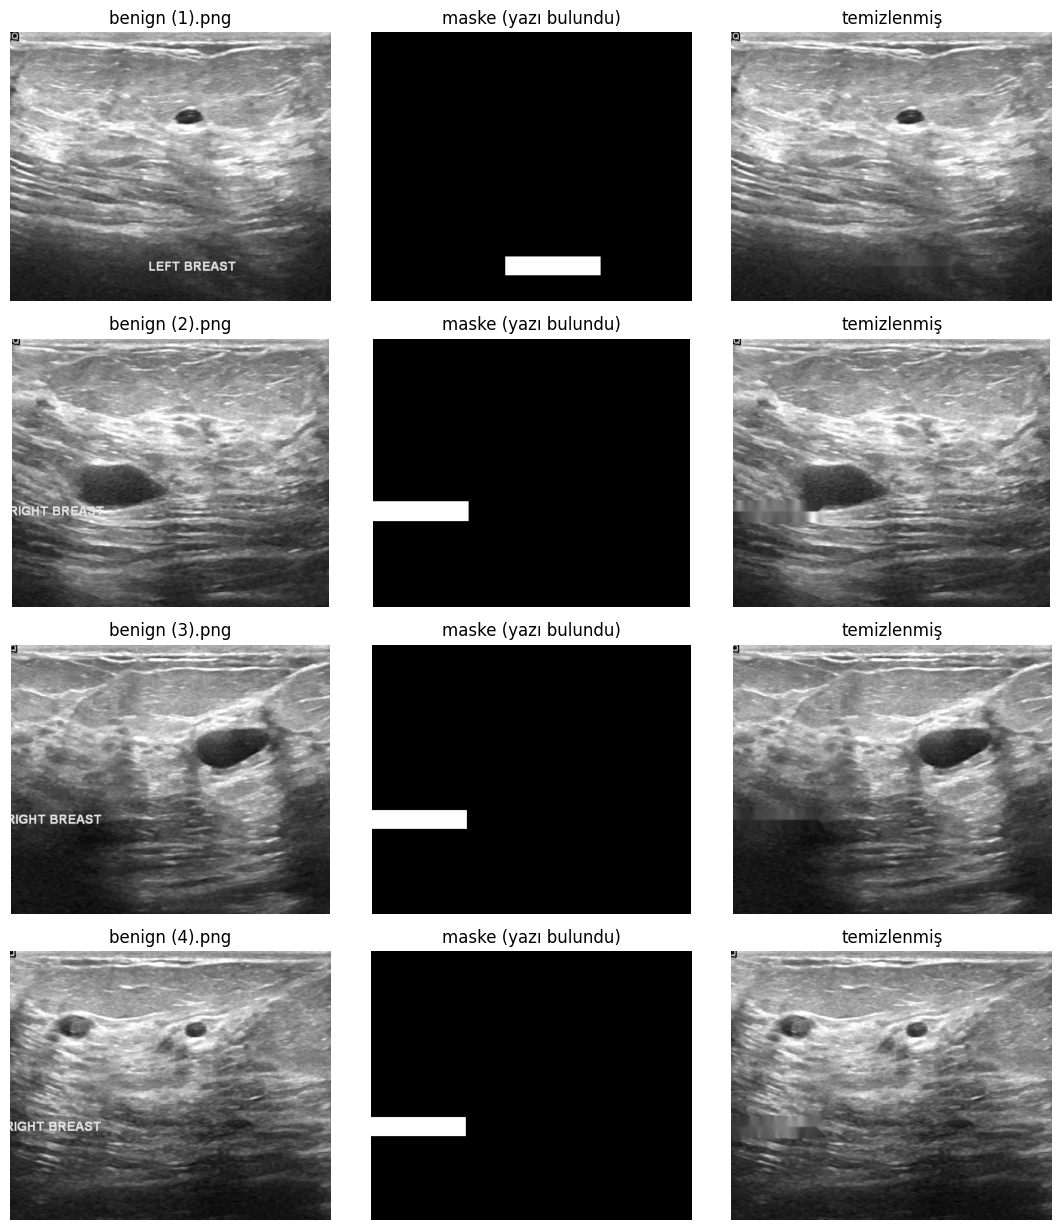

In [ ]:
# Belirli (kesin yazılı) görüntülerde önizleme
PICK = ["benign (1)", "benign (2)", "benign (3)", "benign (4)"]   # istediğini ekle/çıkar
paths = []
for b in PICK:
    paths += [h for h in glob.glob(f"{RAW}/Dataset_BUSI_with_GT/*/{b}.png")
              if "_mask" not in os.path.basename(h)]

fig, ax = plt.subplots(len(paths), 3, figsize=(11, 3.1*len(paths)))
if len(paths) == 1: ax = ax.reshape(1, -1)
for r, sp in enumerate(paths):
    bgr = cv2.imread(sp); cleaned, m = remove_text(bgr)
    tag = " (yazı bulundu)" if m.sum() > 0 else " (BOŞ — yazı yok)"
    ax[r,0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); ax[r,0].set_title(os.path.basename(sp))
    ax[r,1].imshow(m, cmap="gray"); ax[r,1].set_title("maske" + tag)
    ax[r,2].imshow(cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB)); ax[r,2].set_title("temizlenmiş")
    for c in range(3): ax[r,c].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
!pip -q install easyocr
import easyocr, glob, os, cv2, numpy as np, pandas as pd, random
from tqdm.auto import tqdm
reader = easyocr.Reader(['en'], gpu=True)

def clean_one(bgr, conf_thr=0.3, pad=4):
    res = reader.readtext(bgr, detail=1, paragraph=False)
    m = np.zeros(bgr.shape[:2], np.uint8)
    for box, txt, conf in res:
        if conf >= conf_thr:
            cv2.fillConvexPoly(m, np.array(box).astype(np.int32), 1)
    if m.sum() == 0:
        return bgr
    m = cv2.dilate(m, np.ones((2*pad+1, 2*pad+1), np.uint8), 1)
    return cv2.inpaint(bgr, (m*255).astype(np.uint8), 3, cv2.INPAINT_TELEA)

# eski processed'i temizle (RAW'dan yeniden üretilecek)
for sub in ["images", "masks"]:
    os.makedirs(f"{PROC}/{sub}", exist_ok=True)
    for f in glob.glob(f"{PROC}/{sub}/*.png"): os.remove(f)

classes = ["benign", "malignant", "normal"]; src = f"{RAW}/Dataset_BUSI_with_GT"; rows = []; changed = 0
for cls in classes:
    folder = os.path.join(src, cls)
    if not os.path.isdir(folder): continue
    for ip in tqdm(sorted([f for f in glob.glob(f"{folder}/*.png") if "_mask" not in os.path.basename(f)]), desc=cls):
        base = os.path.splitext(os.path.basename(ip))[0]
        m = None
        for mp in sorted(glob.glob(os.path.join(folder, base + "_mask*.png"))):
            mm = cv2.imread(mp, 0)
            if mm is not None: m = mm if m is None else cv2.bitwise_or(m, mm)
        if m is None: m = np.zeros(cv2.imread(ip, 0).shape, np.uint8)
        _, mb = cv2.threshold(m, 127, 255, cv2.THRESH_BINARY)
        name = (f"{cls}_{base}.png").replace(" ", "_").replace("(", "").replace(")", "")
        orig = cv2.imread(ip)
        cleaned = clean_one(orig)                         # ← TEMİZLENMİŞ olan yazılıyor
        cv2.imwrite(f"{PROC}/images/{name}", cleaned)
        cv2.imwrite(f"{PROC}/masks/{name}", mb)
        if not np.array_equal(orig, cleaned): changed += 1
        rows.append({"image": f"{PROC}/images/{name}", "mask": f"{PROC}/masks/{name}", "cls": cls})

df = pd.DataFrame(rows)
if not INCLUDE_NORMAL: df = df[df.cls != "normal"].reset_index(drop=True)
df.to_csv(f"{SPL}/manifest.csv", index=False)
print(f"Yazıldı: {len(df)} görüntü | temizlenen (orijinalden farklı): {changed}")

# DOĞRULAMA: kaydedilmiş dosyaları tekrar oku, yazı kalmış mı?
for sp in random.sample(df.image.tolist(), 5):
    txt = reader.readtext(cv2.imread(sp), detail=0, paragraph=False)
    print(os.path.basename(sp), "| kayıtlı dosyada yazı:", txt if txt else "YOK")

benign:   0%|          | 0/437 [00:00<?, ?it/s]

malignant:   0%|          | 0/210 [00:00<?, ?it/s]

normal:   0%|          | 0/133 [00:00<?, ?it/s]

Yazıldı: 780 görüntü | temizlenen (orijinalden farklı): 178
normal_normal_105.png | kayıtlı dosyada yazı: YOK
benign_benign_201.png | kayıtlı dosyada yazı: YOK
benign_benign_121.png | kayıtlı dosyada yazı: YOK
normal_normal_80.png | kayıtlı dosyada yazı: YOK
benign_benign_352.png | kayıtlı dosyada yazı: YOK


## Bölüm 3 — Split (stratified %20 hold-out test + %80'de 5-fold)
Manifesto dosyaları Drive'a kaydedilir. **Aşağıdaki özet tabloyu onaylamadan eğitime geçme.**

In [ ]:
# Bölüm 3 — Split
from sklearn.model_selection import train_test_split, StratifiedKFold

df = pd.read_csv(f"{SPL}/manifest.csv")
tr_pool, test = train_test_split(df, test_size=TEST_FRAC, stratify=df.cls, random_state=SEED)
tr_pool = tr_pool.reset_index(drop=True); test = test.reset_index(drop=True)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
tr_pool["fold"] = -1
for f, (_, vi) in enumerate(skf.split(tr_pool, tr_pool.cls)):
    tr_pool.loc[vi, "fold"] = f

test.to_csv(f"{SPL}/test.csv", index=False)
tr_pool.to_csv(f"{SPL}/folds.csv", index=False)

# Sızıntı kontrolü (inşa gereği boş olmalı)
assert set(test.image) & set(tr_pool.image) == set(), "SIZINTI: test ve train_pool kesişiyor!"

print("=== TEST SETİ (hold-out) ===")
print(test.cls.value_counts(), "\nToplam test:", len(test))
print("\n=== FOLD x SINIF (train_pool) ===")
print(pd.crosstab(tr_pool.fold, tr_pool.cls, margins=True))


=== TEST SETİ (hold-out) ===
cls
benign       87
malignant    42
normal       27
Name: count, dtype: int64 
Toplam test: 156

=== FOLD x SINIF (train_pool) ===
cls   benign  malignant  normal  All
fold                                
0         70         34      21  125
1         70         34      21  125
2         70         34      21  125
3         70         33      22  125
4         70         33      21  124
All      350        168     106  624


## Bölüm 4 — Metrikler (tek kaynak)
Boş GT + boş tahmin = 1.0 (normal görüntüler için doğru karar). Toplama aşamasında hem tüm-sınıf hem **sadece-lezyon** ortalaması raporlanır.

In [ ]:
# Bölüm 4 — metrik fonksiyonu
def calc_metrics(pred, gt):
    yp = pred.flatten().astype(np.uint8)
    yt = gt.flatten().astype(np.uint8)
    TP = int(((yt == 1) & (yp == 1)).sum())
    TN = int(((yt == 0) & (yp == 0)).sum())
    FP = int(((yt == 0) & (yp == 1)).sum())
    FN = int(((yt == 1) & (yp == 0)).sum())
    eps = 1e-8
    acc = (TP + TN) / (TP + TN + FP + FN + eps)
    if yt.sum() == 0 and yp.sum() == 0:
        return dict(acc=1.0, dice=1.0, iou=1.0, prec=1.0, rec=1.0)
    prec = TP / (TP + FP + eps)
    rec  = TP / (TP + FN + eps)
    dice = 2 * TP / (2 * TP + FP + FN + eps)
    iou  = TP / (TP + FP + FN + eps)
    return dict(acc=acc, dice=dice, iou=iou, prec=prec, rec=rec)

def summarize(d, by=("mode", "method")):
    by = list(by)
    g_all = (d.groupby(by)[["dice", "iou", "acc"]].mean() * 100).round(2)
    g_les = (d[d.cls != "normal"].groupby(by)[["dice", "iou", "acc"]].mean() * 100).round(2)
    return g_all, g_les


## Bölüm 5 — Klasik yöntemler (oracle + otomatik)
`oracle`: ROI/tohum **GT'den** türetilir → klinikte uygulanamaz, **üst-sınır** referansı.
`auto`: GT kullanılmaz; yoğunluk/Otsu tabanlı kaba aday + merkeze yakın en büyük bileşen ile tohum bulunur → adil karşılaştırma.

In [ ]:
# Bölüm 5 — tohumlama + yöntemler + değerlendirme
def roi_from(cx, cy, area, shape):
    h, w = shape
    r = int(math.sqrt(max(area, 1) / math.pi))
    box = max(25, int(r * 1.6))
    x1, y1 = max(0, cx - box), max(0, cy - box)
    x2, y2 = min(w, cx + box), min(h, cy + box)
    return x1, y1, x2, y2, r

def oracle_seed(gt):
    cnts, _ = cv2.findContours(gt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    M = cv2.moments(c)
    if M["m00"] == 0:
        return None
    return int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"]), float(cv2.contourArea(c))

def auto_seed(img):
    cl = cv2.createCLAHE(2.0, (8, 8)).apply(img)
    b = cv2.medianBlur(cl, 5); b = cv2.bilateralFilter(b, 9, 75, 75)
    _, th = cv2.threshold(b, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    n, lab, stats, cent = cv2.connectedComponentsWithStats(th)
    if n <= 1:
        return None
    h, w = img.shape; best, bestscore = None, -1e9
    for i in range(1, n):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < 50:
            continue
        cx, cy = cent[i]
        d = math.hypot(cx - w/2, cy - h/2)
        score = area - 0.5 * d
        if score > bestscore:
            bestscore = score; best = (int(cx), int(cy), float(area))
    return best

def m_watershed(img, cx, cy, area):
    *_, r = roi_from(cx, cy, area, img.shape)
    markers = np.zeros(img.shape[:2], np.int32)
    cv2.circle(markers, (cx, cy), int(r * 2.5), 1, 3)
    cv2.circle(markers, (cx, cy), max(3, int(r * 0.5)), 2, -1)
    blur = cv2.medianBlur(img, 5); blur = cv2.bilateralFilter(blur, 9, 75, 75)
    rgb = cv2.cvtColor(blur, cv2.COLOR_GRAY2RGB)
    markers = cv2.watershed(rgb, markers)
    mask = np.where(markers == 2, 1, 0).astype(np.uint8)
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

def m_otsu(img, cx, cy, area):
    x1, y1, x2, y2, _ = roi_from(cx, cy, area, img.shape)
    roi = img[y1:y2, x1:x2]
    if roi.size == 0:
        return np.zeros_like(img)
    roi = cv2.createCLAHE(2.0, (8, 8)).apply(roi)
    roi = cv2.medianBlur(roi, 5); roi = cv2.bilateralFilter(roi, 9, 75, 75)
    _, t = cv2.threshold(roi, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mask = np.zeros_like(img, np.uint8); mask[y1:y2, x1:x2] = t
    return cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

def m_region(img, cx, cy, area):
    x1, y1, x2, y2, _ = roi_from(cx, cy, area, img.shape)
    roi = img[y1:y2, x1:x2]
    if roi.size == 0:
        return np.zeros_like(img)
    roi = cv2.createCLAHE(2.0, (8, 8)).apply(roi)
    roi = cv2.medianBlur(roi, 5); roi = cv2.bilateralFilter(roi, 9, 75, 75)
    h, w = roi.shape
    ff = np.zeros((h + 2, w + 2), np.uint8)
    sx, sy = cx - x1, cy - y1
    if not (0 <= sx < w and 0 <= sy < h):
        return np.zeros_like(img)
    flags = 4 | (1 << 8) | cv2.FLOODFILL_FIXED_RANGE | cv2.FLOODFILL_MASK_ONLY
    cv2.floodFill(roi, ff, (sx, sy), 1, loDiff=15, upDiff=15, flags=flags)
    rm = ff[1:-1, 1:-1]
    rm = cv2.morphologyEx(rm, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    mask = np.zeros_like(img, np.uint8); mask[y1:y2, x1:x2] = rm
    return mask

METHODS = {"Watershed": m_watershed, "Otsu": m_otsu, "RegionGrowing": m_region}

test = pd.read_csv(f"{SPL}/test.csv")
rows = []
for _, r in tqdm(test.iterrows(), total=len(test), desc="Klasik"):
    img = cv2.imread(r.image, cv2.IMREAD_GRAYSCALE); img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    g = cv2.imread(r["mask"], cv2.IMREAD_GRAYSCALE)
    g = cv2.resize(g, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    _, gt = cv2.threshold(g, 127, 1, cv2.THRESH_BINARY)
    for mode in ["oracle", "auto"]:
        seed = oracle_seed(gt) if mode == "oracle" else auto_seed(img)
        for mname, fn in METHODS.items():
            pred = np.zeros_like(gt) if seed is None else fn(img, int(seed[0]), int(seed[1]), seed[2])
            mt = calc_metrics(pred, gt)
            rows.append({"file": os.path.basename(r.image), "cls": r.cls,
                         "mode": mode, "method": mname, **mt})

cdf = pd.DataFrame(rows)
cdf.to_csv(f"{OUT}/classical_results.csv", index=False)
g_all, g_les = summarize(cdf)
print("=== KLASİK — TÜM SINIFLAR (%) ===\n", g_all)
print("\n=== KLASİK — SADECE LEZYON (%) ===\n", g_les)


Klasik:   0%|          | 0/156 [00:00<?, ?it/s]

=== KLASİK — TÜM SINIFLAR (%) ===
                        dice    iou    acc
mode   method                            
auto   Otsu           17.37  10.83  52.35
       RegionGrowing   5.90   3.56  81.51
       Watershed      14.69   8.99  19.94
oracle Otsu           69.62  56.80  90.70
       RegionGrowing  55.03  43.72  92.39
       Watershed      80.87  70.35  91.84

=== KLASİK — SADECE LEZYON (%) ===
                        dice    iou    acc
mode   method                            
auto   Otsu           21.00  13.10  52.98
       RegionGrowing   7.14   4.31  80.77
       Watershed      17.77  10.87  21.53
oracle Otsu           63.26  47.76  88.75
       RegionGrowing  45.62  31.94  90.79
       Watershed      76.86  64.14  90.13


## Bölüm 6 — Derin öğrenme bileşenleri
UNet++ / EfficientNet-B4 (SCSE attention) + hibrit kayıp (BCE + Dice + Focal Tversky). Manifesto CSV'lerinden okur.

In [ ]:
# Bölüm 6 — dataset / model / loss
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.optim.swa_utils import AveragedModel, update_bn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

MEAN = (0.485, 0.456, 0.406); STD = (0.229, 0.224, 0.225)
train_tfm = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.25), A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.12, rotate_limit=20, border_mode=0, p=0.5),
    A.ElasticTransform(alpha=60, sigma=5, p=0.2),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
    A.GaussNoise(var_limit=(5, 20), p=0.25), A.CLAHE(clip_limit=3, p=0.3),
    A.CoarseDropout(max_holes=4, max_height=20, max_width=20, fill_value=0, mask_fill_value=0, p=0.2),
    A.Normalize(mean=MEAN, std=STD), ToTensorV2(),
])
val_tfm = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

class BUSIDataset(Dataset):
    def __init__(self, frame, tfm):
        self.df = frame.reset_index(drop=True); self.tfm = tfm
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.cvtColor(cv2.imread(r.image), cv2.COLOR_BGR2RGB)
        msk = cv2.imread(r["mask"], cv2.IMREAD_GRAYSCALE)
        msk = (msk > 127).astype(np.float32)
        a = self.tfm(image=img, mask=msk)
        return a["image"].float(), a["mask"].unsqueeze(0).float()

def build_model(pretrained=True):
    return smp.UnetPlusPlus(
        encoder_name=ENCODER,
        encoder_weights="imagenet" if pretrained else None,
        in_channels=3, classes=1, activation=None,
        decoder_channels=(256, 128, 64, 32, 16),
        decoder_attention_type="scse",
    ).to(DEVICE)

class DiceLoss(nn.Module):
    def __init__(self, s=1.): super().__init__(); self.s = s
    def forward(self, logit, t):
        p = torch.sigmoid(logit).view(logit.size(0), -1); t = t.view(t.size(0), -1)
        return 1 - ((2 * (p * t).sum(1) + self.s) / (p.sum(1) + t.sum(1) + self.s)).mean()

class FocalTverskyLoss(nn.Module):
    def __init__(self, a=0.3, b=0.7, g=0.75, s=1.):
        super().__init__(); self.a, self.b, self.g, self.s = a, b, g, s
    def forward(self, logit, t):
        p = torch.sigmoid(logit).view(logit.size(0), -1); t = t.view(t.size(0), -1)
        tp = (p * t).sum(1); fp = (p * (1 - t)).sum(1); fn = ((1 - p) * t).sum(1)
        ti = (tp + self.s) / (tp + self.a * fp + self.b * fn + self.s)
        return (1 - ti).pow(self.g).mean()

class SegLoss(nn.Module):
    def __init__(self):
        super().__init__(); self.d = DiceLoss(); self.f = FocalTverskyLoss(); self.b = nn.BCEWithLogitsLoss()
    def forward(self, p, t):
        return 0.4 * self.d(p, t) + 0.4 * self.f(p, t) + 0.2 * self.b(p, t)

@torch.no_grad()
def dice_coeff(logit, t, thr=0.5):
    p = (torch.sigmoid(logit) > thr).float().view(logit.size(0), -1); t = t.view(t.size(0), -1)
    return ((2 * (p * t).sum(1) + 1) / (p.sum(1) + t.sum(1) + 1)).mean().item()


Device: cuda


## Bölüm 7 — Eğitim (5-fold, resume destekli)
Her fold ayrı eğitilir ve en iyi checkpoint Drive'a kaydedilir. **Oturum koparsa hücreyi tekrar çalıştır** — tamamlanmış foldlar atlanır, eksik kalan fold'dan devam edilir. SWA son %20 epoch'ta uygulanır.

In [ ]:
# Bölüm 7 — eğitim
folds_df = pd.read_csv(f"{SPL}/folds.csv")

def train_one_fold(f):
    ckpt = f"{CKPT}/fold{f+1}_best.pth"
    if os.path.exists(ckpt):
        print(f"Fold {f+1}: checkpoint var, atlanıyor.")
        return ckpt
    set_seed(SEED + f)
    tr = folds_df[folds_df.fold != f]; vl = folds_df[folds_df.fold == f]
    tr_dl = DataLoader(BUSIDataset(tr, train_tfm), batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=2, pin_memory=True, drop_last=True)
    vl_dl = DataLoader(BUSIDataset(vl, val_tfm), batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=True)
    model = build_model(pretrained=True); crit = SegLoss()
    enc = list(model.encoder.parameters())
    dec = [p for n, p in model.named_parameters() if "encoder" not in n]
    opt = torch.optim.AdamW([{"params": enc, "lr": LR_INIT * 0.1},
                             {"params": dec, "lr": LR_INIT}], weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=8, min_lr=1e-6)
    scaler = GradScaler()
    swa_model = AveragedModel(model); swa_start = int(0.8 * NUM_EPOCHS)
    best, no_imp, hist = 0.0, 0, []
    for ep in range(1, NUM_EPOCHS + 1):
        model.train()
        for x, y in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with autocast():
                loss = crit(model(x), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
        model.eval(); vd = 0.0
        with torch.no_grad():
            for x, y in vl_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                with autocast():
                    vd += dice_coeff(model(x), y)
        vd /= max(len(vl_dl), 1); hist.append(vd); sch.step(vd)
        if ep >= swa_start:
            swa_model.update_parameters(model)
        if vd > best:
            best = vd; torch.save(model.state_dict(), ckpt); no_imp = 0; tag = " *"
        else:
            no_imp += 1; tag = ""
        if ep % 5 == 0 or tag:
            print(f"  Fold{f+1} E{ep:03d} ValDSC={vd:.4f} Best={best:.4f}{tag}")
        if no_imp >= PATIENCE:
            print(f"  Fold{f+1}: erken durdurma @E{ep}"); break
    # SWA değerlendir
    try:
        update_bn(tr_dl, swa_model, device=DEVICE)
        swa_model.eval(); sd = 0.0
        with torch.no_grad():
            for x, y in vl_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                with autocast():
                    sd += dice_coeff(swa_model(x), y)
        sd /= max(len(vl_dl), 1)
        if sd > best:
            print(f"  Fold{f+1}: SWA daha iyi ({sd:.4f} > {best:.4f}), SWA kaydediliyor.")
            torch.save(swa_model.module.state_dict(), ckpt)
    except Exception as e:
        print("  SWA atlandı:", e)
    pd.DataFrame({"val_dice": hist}).to_csv(f"{OUT}/train_fold{f+1}.csv", index=False)
    return ckpt

for f in range(N_FOLDS):
    train_one_fold(f)
print("Eğitim tamam. Checkpoint'ler:", sorted(glob.glob(f"{CKPT}/fold*_best.pth")))


Fold 1: checkpoint var, atlanıyor.


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 77.9MB            

model.safetensors: downloading bytes:           |  0.00B            

  Fold2 E001 ValDSC=0.3445 Best=0.3445 *
  Fold2 E002 ValDSC=0.4615 Best=0.4615 *
  Fold2 E003 ValDSC=0.5062 Best=0.5062 *
  Fold2 E004 ValDSC=0.5343 Best=0.5343 *
  Fold2 E005 ValDSC=0.5879 Best=0.5879 *
  Fold2 E007 ValDSC=0.6597 Best=0.6597 *
  Fold2 E010 ValDSC=0.6778 Best=0.6778 *
  Fold2 E014 ValDSC=0.6801 Best=0.6801 *
  Fold2 E015 ValDSC=0.6646 Best=0.6801
  Fold2 E019 ValDSC=0.6803 Best=0.6803 *
  Fold2 E020 ValDSC=0.7099 Best=0.7099 *
  Fold2 E024 ValDSC=0.7211 Best=0.7211 *
  Fold2 E025 ValDSC=0.7217 Best=0.7217 *
  Fold2 E026 ValDSC=0.7419 Best=0.7419 *
  Fold2 E027 ValDSC=0.7676 Best=0.7676 *
  Fold2 E030 ValDSC=0.7780 Best=0.7780 *
  Fold2 E035 ValDSC=0.7347 Best=0.7780
  Fold2 E040 ValDSC=0.7371 Best=0.7780
  Fold2 E045 ValDSC=0.7842 Best=0.7842 *
  Fold2 E050 ValDSC=0.7662 Best=0.7842
  Fold2 E055 ValDSC=0.7675 Best=0.7842
  Fold2 E060 ValDSC=0.7942 Best=0.7942 *
  Fold2 E061 ValDSC=0.7993 Best=0.7993 *
  Fold2 E065 ValDSC=0.7773 Best=0.7993
  Fold2 E070 ValDSC=0.7797 B

## Bölüm 8 — Sızıntısız değerlendirme (ensemble + TTA, yalnız test)
5 modelin TTA ortalaması **yalnız hold-out test** üzerinde hesaplanır. DSC hem tüm-sınıf hem sadece-lezyon olarak verilir.

In [ ]:
# Bölüm 8 — ensemble + TTA, test üzerinde
ckpts = sorted(glob.glob(f"{CKPT}/fold*_best.pth"))
assert len(ckpts) > 0, "Checkpoint yok — önce Bölüm 7."
models = []
for c in ckpts:
    m = build_model(pretrained=False); m.load_state_dict(torch.load(c, map_location=DEVICE)); m.eval()
    models.append(m)

@torch.no_grad()
def ensemble_tta(x):
    x = x.unsqueeze(0).to(DEVICE); preds = []
    for m in models:
        for flips in [[], [2], [3], [2, 3]]:
            xi = x.clone()
            for fp in flips: xi = torch.flip(xi, [fp])
            p = torch.sigmoid(m(xi))
            for fp in flips: p = torch.flip(p, [fp])
            preds.append(p.cpu())
    return torch.stack(preds).mean(0).squeeze(0)

test = pd.read_csv(f"{SPL}/test.csv")
# sızıntı güvencesi
folds_df = pd.read_csv(f"{SPL}/folds.csv")
assert set(test.image) & set(folds_df.image) == set(), "SIZINTI: test eğitimde!"

ds = BUSIDataset(test, val_tfm)
rows = []
for i in tqdm(range(len(ds)), desc="DL test"):
    x, y = ds[i]
    p = ensemble_tta(x).squeeze().numpy()
    pred = (p > 0.5).astype(np.uint8)
    gt = y.squeeze().numpy().astype(np.uint8)
    mt = calc_metrics(pred, gt)
    rows.append({"file": os.path.basename(test.iloc[i].image), "cls": test.iloc[i].cls,
                 "mode": "dl", "method": "UNet++Ensemble", **mt})
ddf = pd.DataFrame(rows)
ddf.to_csv(f"{OUT}/dl_test_metrics.csv", index=False)

def ms(d):
    return {k: (round(d[k].mean()*100, 2), round(d[k].std()*100, 2)) for k in ["dice", "iou", "acc"]}
print("DL — TÜM SINIFLAR (ort, std) %:", ms(ddf))
print("DL — SADECE LEZYON (ort, std) %:", ms(ddf[ddf.cls != "normal"]))


DL test:   0%|          | 0/156 [00:00<?, ?it/s]

DL — TÜM SINIFLAR (ort, std) %: {'dice': (np.float64(80.63), 28.25), 'iou': (np.float64(74.18), 28.67), 'acc': (np.float64(96.79), 5.01)}
DL — SADECE LEZYON (ort, std) %: {'dice': (np.float64(80.45), 25.46), 'iou': (np.float64(72.65), 25.76), 'acc': (np.float64(96.2), 5.31)}


## Bölüm 9 — Karşılaştırma + per-class + istatistik + figürler
Klasik (oracle/auto) ile DL aynı test setinde; sınıf bazlı kırılım; DL vs en iyi klasik(auto) eşli **Wilcoxon**; bootstrap %95 GA; boxplot ve nitel ızgara.

=== TÜM SINIFLAR (%) ===
                         dice    iou    acc
mode   method                             
auto   Otsu            17.37  10.83  52.35
       RegionGrowing    5.90   3.56  81.51
       Watershed       14.69   8.99  19.94
dl     UNet++Ensemble  80.63  74.18  96.79
oracle Otsu            69.62  56.80  90.70
       RegionGrowing   55.03  43.72  92.39
       Watershed       80.87  70.35  91.84

=== SADECE LEZYON (%) ===
                         dice    iou    acc
mode   method                             
auto   Otsu            21.00  13.10  52.98
       RegionGrowing    7.14   4.31  80.77
       Watershed       17.77  10.87  21.53
dl     UNet++Ensemble  80.45  72.65  96.20
oracle Otsu            63.26  47.76  88.75
       RegionGrowing   45.62  31.94  90.79
       Watershed       76.86  64.14  90.13

Wilcoxon (DL vs Otsu-auto, lezyon, n=129): p = 3.462e-22
DL lezyon DSC %95 GA: (np.float64(75.99), np.float64(84.71))


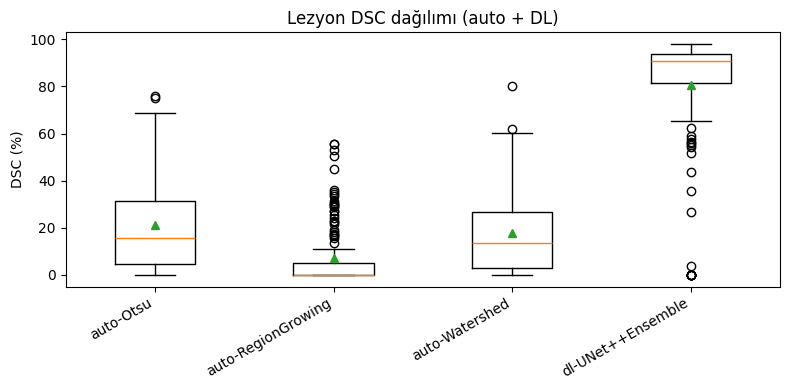

In [ ]:
# Bölüm 9 — karşılaştırma + istatistik
from scipy.stats import wilcoxon

cdf = pd.read_csv(f"{OUT}/classical_results.csv")
ddf = pd.read_csv(f"{OUT}/dl_test_metrics.csv")
allm = pd.concat([cdf, ddf], ignore_index=True)

def table(d):
    a = (d.groupby(["mode", "method"])[["dice", "iou", "acc"]].mean() * 100).round(2)
    l = (d[d.cls != "normal"].groupby(["mode", "method"])[["dice", "iou", "acc"]].mean() * 100).round(2)
    return a, l
ta, tl = table(allm)
print("=== TÜM SINIFLAR (%) ===\n", ta)
print("\n=== SADECE LEZYON (%) ===\n", tl)
ta.to_csv(f"{OUT}/table_all.csv"); tl.to_csv(f"{OUT}/table_lesion.csv")

# DL vs en iyi klasik(auto) — sadece lezyon, dosya eşli Wilcoxon
les = allm[allm.cls != "normal"]
auto = les[les["mode"] == "auto"]
best_cl = auto.groupby("method")["dice"].mean().idxmax()
A = les[(les["mode"] == "auto") & (les.method == best_cl)].set_index("file")["dice"]
B = les[(les["mode"] == "dl")].set_index("file")["dice"]
common = A.index.intersection(B.index)
if len(common) > 10:
    stat, p = wilcoxon(B.loc[common], A.loc[common])
    print(f"\nWilcoxon (DL vs {best_cl}-auto, lezyon, n={len(common)}): p = {p:.3e}")

# bootstrap %95 GA (DL lezyon dice)
def boot_ci(v, n=2000):
    v = np.asarray(v); idx = np.random.randint(0, len(v), (n, len(v)))
    means = v[idx].mean(1) * 100
    return round(np.percentile(means, 2.5), 2), round(np.percentile(means, 97.5), 2)
print("DL lezyon DSC %95 GA:", boot_ci(B.loc[common].values))

# boxplot
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = les[les["mode"].isin(["auto", "dl"])].copy()
plot_df["grup"] = plot_df["mode"] + "-" + plot_df["method"]
order = sorted(plot_df.grup.unique())
ax.boxplot([plot_df[plot_df.grup == g].dice.values * 100 for g in order], labels=order, showmeans=True)
ax.set_ylabel("DSC (%)"); ax.set_title("Lezyon DSC dağılımı (auto + DL)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.savefig(f"{OUT}/boxplot_dsc.png", dpi=150, bbox_inches="tight"); plt.show()


## Bölüm 10 — (Opsiyonel) Ablasyon ve dış doğrulama
Aşağıdakiler ek GPU/veri gerektirir; `RUN_ABLATION` / dış veri yolu ayarlandığında çalışır.
- **Ablasyon:** tek-fold vs ensemble, TTA aç/kapa (mevcut checkpoint'lerle, ek eğitim gerekmez). Loss ablasyonu (yalnız BCE / yalnız Dice) **yeniden eğitim** ister.
- **Dış doğrulama:** ikinci veri setini (UDIAT/Dataset B veya BUSIS) `processed/` ile aynı formata getirip aynı `ensemble_tta` ile değerlendir.

In [ ]:
# Bölüm 10 — opsiyonel ablasyon (mevcut checkpoint'lerle: tek-fold vs ensemble, TTA aç/kapa)
RUN_ABLATION = True
if RUN_ABLATION:
    test = pd.read_csv(f"{SPL}/test.csv"); ds = BUSIDataset(test, val_tfm)

    @torch.no_grad()
    def single_no_tta(x):
        return torch.sigmoid(models[0](x.unsqueeze(0).to(DEVICE))).cpu().squeeze(0)

    @torch.no_grad()
    def ensemble_no_tta(x):
        x = x.unsqueeze(0).to(DEVICE)
        ps = [torch.sigmoid(m(x)).cpu() for m in models]
        return torch.stack(ps).mean(0).squeeze(0)

    variants = {"single_noTTA": single_no_tta, "ensemble_noTTA": ensemble_no_tta, "ensemble_TTA": ensemble_tta}
    arows = []
    for name, fn in variants.items():
        for i in range(len(ds)):
            x, y = ds[i]; pred = (fn(x).squeeze().numpy() > 0.5).astype(np.uint8)
            gt = y.squeeze().numpy().astype(np.uint8); mt = calc_metrics(pred, gt)
            arows.append({"variant": name, "cls": test.iloc[i].cls, **mt})
    adf = pd.DataFrame(arows)
    print((adf[adf.cls != "normal"].groupby("variant")[["dice", "iou"]].mean() * 100).round(2))
    adf.to_csv(f"{OUT}/ablation.csv", index=False)
else:
    print("RUN_ABLATION=False — ablasyon atlandı.")


                 dice    iou
variant                     
ensemble_TTA    80.45  72.65
ensemble_noTTA  80.78  72.80
single_noTTA    78.64  70.39


## Hücre 1 — Plain UNet kurucu (Bölüm 11)

In [ ]:
# Bölüm 11 — Plain UNet (EfficientNet-B4 + SCSE), UNet++ ile tek fark: nested skip yok
def build_unet(pretrained=True):
    return smp.Unet(
        encoder_name=ENCODER,                       # aynı: efficientnet-b4
        encoder_weights="imagenet" if pretrained else None,
        in_channels=3, classes=1, activation=None,
        decoder_channels=(256, 128, 64, 32, 16),    # aynı decoder genişlikleri
        decoder_attention_type="scse",              # aynı: SCSE attention
    ).to(DEVICE)

CKPT_UNET = CKPT  # aynı klasör; isim öneki "unet_" olduğu için çakışmaz
print("build_unet hazır. Encoder:", ENCODER)

build_unet hazır. Encoder: efficientnet-b4


## Hücre 2 — UNet eğitimi (5-fold, resume destekli, ayrı checkpoint)

In [ ]:
# Bölüm 12 — UNet eğitimi (Bölüm 7 ile birebir aynı protokol, sadece model + ckpt adı farklı)
folds_df = pd.read_csv(f"{SPL}/folds.csv")

def train_one_fold_unet(f):
    ckpt = f"{CKPT_UNET}/unet_fold{f+1}_best.pth"
    if os.path.exists(ckpt):
        print(f"UNet Fold {f+1}: checkpoint var, atlanıyor.")
        return ckpt
    set_seed(SEED + f)
    tr = folds_df[folds_df.fold != f]; vl = folds_df[folds_df.fold == f]
    tr_dl = DataLoader(BUSIDataset(tr, train_tfm), batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=2, pin_memory=True, drop_last=True)
    vl_dl = DataLoader(BUSIDataset(vl, val_tfm), batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=True)
    model = build_unet(pretrained=True); crit = SegLoss()
    enc = list(model.encoder.parameters())
    dec = [p for n, p in model.named_parameters() if "encoder" not in n]
    opt = torch.optim.AdamW([{"params": enc, "lr": LR_INIT * 0.1},
                             {"params": dec, "lr": LR_INIT}], weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=8, min_lr=1e-6)
    scaler = GradScaler()
    swa_model = AveragedModel(model); swa_start = int(0.8 * NUM_EPOCHS)
    best, no_imp, hist = 0.0, 0, []
    for ep in range(1, NUM_EPOCHS + 1):
        model.train()
        for x, y in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with autocast():
                loss = crit(model(x), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
        model.eval(); vd = 0.0
        with torch.no_grad():
            for x, y in vl_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                with autocast():
                    vd += dice_coeff(model(x), y)
        vd /= max(len(vl_dl), 1); hist.append(vd); sch.step(vd)
        if ep >= swa_start:
            swa_model.update_parameters(model)
        if vd > best:
            best = vd; torch.save(model.state_dict(), ckpt); no_imp = 0; tag = " *"
        else:
            no_imp += 1; tag = ""
        if ep % 5 == 0 or tag:
            print(f"  UNet Fold{f+1} E{ep:03d} ValDSC={vd:.4f} Best={best:.4f}{tag}")
        if no_imp >= PATIENCE:
            print(f"  UNet Fold{f+1}: erken durdurma @E{ep}"); break
    try:
        update_bn(tr_dl, swa_model, device=DEVICE)
        swa_model.eval(); sd = 0.0
        with torch.no_grad():
            for x, y in vl_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                with autocast():
                    sd += dice_coeff(swa_model(x), y)
        sd /= max(len(vl_dl), 1)
        if sd > best:
            print(f"  UNet Fold{f+1}: SWA daha iyi ({sd:.4f} > {best:.4f}), SWA kaydediliyor.")
            torch.save(swa_model.module.state_dict(), ckpt)
    except Exception as e:
        print("  SWA atlandı:", e)
    pd.DataFrame({"val_dice": hist}).to_csv(f"{OUT}/train_unet_fold{f+1}.csv", index=False)
    return ckpt

for f in range(N_FOLDS):
    train_one_fold_unet(f)
print("UNet eğitim tamam. Checkpoint'ler:", sorted(glob.glob(f"{CKPT_UNET}/unet_fold*_best.pth")))

  UNet Fold1 E001 ValDSC=0.3985 Best=0.3985 *
  UNet Fold1 E002 ValDSC=0.4546 Best=0.4546 *
  UNet Fold1 E003 ValDSC=0.4912 Best=0.4912 *
  UNet Fold1 E004 ValDSC=0.5334 Best=0.5334 *
  UNet Fold1 E005 ValDSC=0.5619 Best=0.5619 *
  UNet Fold1 E006 ValDSC=0.5944 Best=0.5944 *
  UNet Fold1 E008 ValDSC=0.6017 Best=0.6017 *
  UNet Fold1 E010 ValDSC=0.6291 Best=0.6291 *
  UNet Fold1 E011 ValDSC=0.6439 Best=0.6439 *
  UNet Fold1 E015 ValDSC=0.6582 Best=0.6582 *
  UNet Fold1 E016 ValDSC=0.6659 Best=0.6659 *
  UNet Fold1 E017 ValDSC=0.6675 Best=0.6675 *
  UNet Fold1 E018 ValDSC=0.6974 Best=0.6974 *
  UNet Fold1 E020 ValDSC=0.6980 Best=0.6980 *
  UNet Fold1 E022 ValDSC=0.7030 Best=0.7030 *
  UNet Fold1 E023 ValDSC=0.7039 Best=0.7039 *
  UNet Fold1 E025 ValDSC=0.7211 Best=0.7211 *
  UNet Fold1 E030 ValDSC=0.7141 Best=0.7211
  UNet Fold1 E034 ValDSC=0.7261 Best=0.7261 *
  UNet Fold1 E035 ValDSC=0.7172 Best=0.7261
  UNet Fold1 E040 ValDSC=0.7374 Best=0.7374 *
  UNet Fold1 E042 ValDSC=0.7443 Best=0

## Hücre 3 — UNet değerlendirme (ensemble + TTA, yalnız test)

In [ ]:
# Bölüm 13 — UNet ensemble + TTA, test üzerinde (Bölüm 8 ile aynı mantık)
unet_ckpts = sorted(glob.glob(f"{CKPT_UNET}/unet_fold*_best.pth"))
assert len(unet_ckpts) > 0, "UNet checkpoint yok — önce Bölüm 12."
unet_models = []
for c in unet_ckpts:
    m = build_unet(pretrained=False); m.load_state_dict(torch.load(c, map_location=DEVICE)); m.eval()
    unet_models.append(m)

@torch.no_grad()
def unet_ensemble_tta(x):
    x = x.unsqueeze(0).to(DEVICE); preds = []
    for m in unet_models:
        for flips in [[], [2], [3], [2, 3]]:
            xi = x.clone()
            for fp in flips: xi = torch.flip(xi, [fp])
            p = torch.sigmoid(m(xi))
            for fp in flips: p = torch.flip(p, [fp])
            preds.append(p.cpu())
    return torch.stack(preds).mean(0).squeeze(0)

test = pd.read_csv(f"{SPL}/test.csv")
folds_df = pd.read_csv(f"{SPL}/folds.csv")
assert set(test.image) & set(folds_df.image) == set(), "SIZINTI: test eğitimde!"

ds = BUSIDataset(test, val_tfm)
rows = []
for i in tqdm(range(len(ds)), desc="UNet test"):
    x, y = ds[i]
    p = unet_ensemble_tta(x).squeeze().numpy()
    pred = (p > 0.5).astype(np.uint8)
    gt = y.squeeze().numpy().astype(np.uint8)
    mt = calc_metrics(pred, gt)
    rows.append({"file": os.path.basename(test.iloc[i].image), "cls": test.iloc[i].cls,
                 "mode": "dl", "method": "UNetEnsemble", **mt})
udf = pd.DataFrame(rows)
udf.to_csv(f"{OUT}/dl_unet_test_metrics.csv", index=False)

def ms(d):
    return {k: (round(d[k].mean()*100, 2), round(d[k].std()*100, 2)) for k in ["dice", "iou", "acc"]}
print("UNet — TÜM SINIFLAR (ort, std) %:", ms(udf))
print("UNet — SADECE LEZYON (ort, std) %:", ms(udf[udf.cls != "normal"]))

UNet test:   0%|          | 0/156 [00:00<?, ?it/s]

UNet — TÜM SINIFLAR (ort, std) %: {'dice': (np.float64(82.89), 25.74), 'iou': (np.float64(76.45), 26.48), 'acc': (np.float64(97.09), 4.53)}
UNet — SADECE LEZYON (ort, std) %: {'dice': (np.float64(82.41), 23.13), 'iou': (np.float64(74.62), 23.73), 'acc': (np.float64(96.55), 4.79)}


## Hücre 4 — Birleşik karşılaştırma + UNet++ vs UNet için Wilcoxon

In [ ]:
# Bölüm 14 — klasik + UNet + UNet++ birleşik tablo, UNet++ vs UNet eşli test
from scipy.stats import wilcoxon

cdf  = pd.read_csv(f"{OUT}/classical_results.csv")
ddf  = pd.read_csv(f"{OUT}/dl_test_metrics.csv")        # UNet++ (mevcut)
udf  = pd.read_csv(f"{OUT}/dl_unet_test_metrics.csv")   # UNet (yeni)
allm = pd.concat([cdf, ddf, udf], ignore_index=True)

def table(d):
    a = (d.groupby(["mode", "method"])[["dice", "iou", "acc"]].mean() * 100).round(2)
    l = (d[d.cls != "normal"].groupby(["mode", "method"])[["dice", "iou", "acc"]].mean() * 100).round(2)
    return a, l
ta, tl = table(allm)
print("=== TÜM SINIFLAR (%) ===\n", ta)
print("\n=== SADECE LEZYON (%) ===\n", tl)
ta.to_csv(f"{OUT}/table_all_v2.csv"); tl.to_csv(f"{OUT}/table_lesion_v2.csv")

# UNet++ vs UNet — sadece lezyon, dosya eşli Wilcoxon
les = allm[allm.cls != "normal"]
PP = les[les.method == "UNet++Ensemble"].set_index("file")["dice"]
UN = les[les.method == "UNetEnsemble"].set_index("file")["dice"]
common = PP.index.intersection(UN.index)
if len(common) > 10:
    stat, p = wilcoxon(PP.loc[common], UN.loc[common])
    print(f"\nWilcoxon (UNet++ vs UNet, lezyon, n={len(common)}): p = {p:.3e}")
    print(f"  UNet++ ort: {PP.loc[common].mean()*100:.2f}  |  UNet ort: {UN.loc[common].mean()*100:.2f}")

=== TÜM SINIFLAR (%) ===
                         dice    iou    acc
mode   method                             
auto   Otsu            17.37  10.83  52.35
       RegionGrowing    5.90   3.56  81.51
       Watershed       14.69   8.99  19.94
dl     UNet++Ensemble  80.63  74.18  96.79
       UNetEnsemble    82.89  76.45  97.09
oracle Otsu            69.62  56.80  90.70
       RegionGrowing   55.03  43.72  92.39
       Watershed       80.87  70.35  91.84

=== SADECE LEZYON (%) ===
                         dice    iou    acc
mode   method                             
auto   Otsu            21.00  13.10  52.98
       RegionGrowing    7.14   4.31  80.77
       Watershed       17.77  10.87  21.53
dl     UNet++Ensemble  80.45  72.65  96.20
       UNetEnsemble    82.41  74.62  96.55
oracle Otsu            63.26  47.76  88.75
       RegionGrowing   45.62  31.94  90.79
       Watershed       76.86  64.14  90.13

Wilcoxon (UNet++ vs UNet, lezyon, n=129): p = 1.999e-01
  UNet++ ort: 80.45  |  UNet 

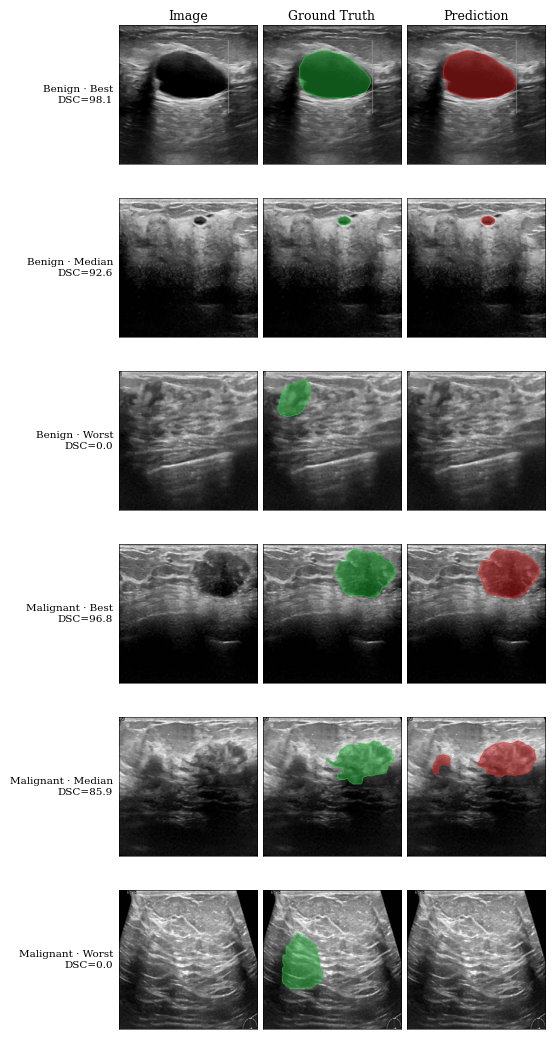

Kaydedildi: /content/drive/MyDrive/BUSI_Project/outputs/fig_qualitative_panel.pdf
Seçilen vakalar:
  benign    Best     benign_benign_330.png        DSC= 98.1
  benign    Median   benign_benign_138.png        DSC= 92.6
  benign    Worst    benign_benign_269.png        DSC=  0.0
  malignant Best     malignant_malignant_87.png   DSC= 96.8
  malignant Median   malignant_malignant_41.png   DSC= 85.9
  malignant Worst    malignant_malignant_81.png   DSC=  0.0


In [ ]:
# =====================================================================
#  ASYU 2026 — Nitel Segmentasyon Paneli (Colab hücresi)
#  Satırlar: benign & malignant × (Best / Median / Worst)
#  Sütunlar: Image | Ground Truth | Prediction   (Şekil 3.2 tarzı)
#  Pipeline notebook ile BİREBİR: UNet++/eff-b4, 5-fold ensemble + TTA, eşik 0.5
# =====================================================================
import os, glob
import numpy as np, pandas as pd, cv2
import matplotlib as mpl, matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 0) AYARLAR  (yolları Colab'a göre düzenle)
# ---------------------------------------------------------------------
BASE = "/content/drive/MyDrive/BUSI_Project"
PROC = f"{BASE}/processed"; CKPT = f"{BASE}/checkpoints"
SPL  = f"{BASE}/splits";    OUT  = f"{BASE}/outputs"

IMG_SIZE = globals().get("IMG_SIZE", 256)
LANG     = "EN"                      # "EN" veya "TR"

# Bindirme renkleri (RGB 0-1) — GT yeşil, Tahmin kırmızı
GT_COLOR, PRED_COLOR, ALPHA = (0.15, 0.80, 0.25), (0.92, 0.15, 0.15), 0.42

TXT = {
    "EN": dict(img="Image", gt="Ground Truth", pred="Prediction",
               best="Best", median="Median", worst="Worst",
               cls={"benign": "Benign", "malignant": "Malignant"}),
    "TR": dict(img="Görüntü", gt="Gerçek Maske", pred="Tahmin",
               best="En İyi", median="Medyan", worst="En Kötü",
               cls={"benign": "Benign", "malignant": "Malignant"}),
}[LANG]

mpl.rcParams.update({"font.family": "serif",
                     "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
                     "pdf.fonttype": 42, "ps.fonttype": 42})

# ---------------------------------------------------------------------
# 1) MODEL — bellekte yoksa checkpoint'leri yükle (notebook ile aynı)
# ---------------------------------------------------------------------
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
ENCODER = globals().get("ENCODER", "efficientnet-b4")

if "val_tfm" not in globals():
    val_tfm = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
                         A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

if "ensemble_tta" not in globals() or "models" not in globals():
    def build_model(pretrained=False):
        return smp.UnetPlusPlus(
            encoder_name=ENCODER,
            encoder_weights="imagenet" if pretrained else None,
            in_channels=3, classes=1, activation=None,
            decoder_channels=(256, 128, 64, 32, 16),
            decoder_attention_type="scse").to(DEVICE)

    models = []
    for c in sorted(glob.glob(f"{CKPT}/fold*_best.pth")):   # unet_fold*'u almaz
        m = build_model(False)
        m.load_state_dict(torch.load(c, map_location=DEVICE)); m.eval()
        models.append(m)
    print(f"Yüklenen checkpoint sayısı: {len(models)}")
    assert len(models) == 5, "5 fold beklendi; checkpoint yolunu kontrol et."

    @torch.no_grad()
    def ensemble_tta(x):
        x = x.unsqueeze(0).to(DEVICE); preds = []
        for m in models:
            for flips in [[], [2], [3], [2, 3]]:
                xi = x.clone()
                for fp in flips: xi = torch.flip(xi, [fp])
                p = torch.sigmoid(m(xi))
                for fp in flips: p = torch.flip(p, [fp])
                preds.append(p.cpu())
        return torch.stack(preds).mean(0).squeeze(0)

# ---------------------------------------------------------------------
# 2) VAKA SEÇİMİ — her sınıftan Best / Median / Worst (DSC'ye göre)
# ---------------------------------------------------------------------
met = pd.read_csv(f"{OUT}/dl_test_metrics.csv")
met["dice_pct"] = met["dice"] * 100 if met["dice"].max() <= 1.5 else met["dice"]

selected = []   # (cls, tag, file, dice_pct)
for cls in ["benign", "malignant"]:
    sub = met[met["cls"] == cls].reset_index(drop=True)
    order = sub["dice_pct"].sort_values()              # artan
    picks = [(TXT["worst"],  order.index[0]),
             (TXT["median"], order.index[len(sub) // 2]),
             (TXT["best"],   order.index[-1])]
    # gösterim sırası: Best, Median, Worst
    for tag, idx in sorted(picks, key=lambda t: sub.loc[t[1], "dice_pct"], reverse=True):
        r = sub.loc[idx]
        selected.append((cls, tag, r["file"], r["dice_pct"]))

# ---------------------------------------------------------------------
# 3) YARDIMCILAR — yükle, tahmin et, bindirme üret
# ---------------------------------------------------------------------
def load_pair(fname):
    img = cv2.cvtColor(cv2.imread(f"{PROC}/images/{fname}"), cv2.COLOR_BGR2RGB)
    gt  = cv2.imread(f"{PROC}/masks/{fname}", cv2.IMREAD_GRAYSCALE)
    gray = cv2.resize(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), (IMG_SIZE, IMG_SIZE))
    gt   = (cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST) > 127).astype(np.uint8)
    return img, gray, gt

def predict(img, gt):
    x = val_tfm(image=img)["image"].float()   # mask'ı verme; sadece görüntü
    prob = ensemble_tta(x).squeeze().cpu().numpy()
    return (prob > 0.5).astype(np.uint8)

def overlay(gray, mask, color):
    rgb = np.dstack([gray] * 3).astype(np.float32) / 255.0
    m = mask.astype(bool)
    rgb[m] = (1 - ALPHA) * rgb[m] + ALPHA * np.array(color)
    rgb8 = (rgb * 255).astype(np.uint8)
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(rgb8, cnts, -1, tuple(int(c * 255) for c in color), 1)
    return rgb8

# ---------------------------------------------------------------------
# 4) PANELİ ÇİZ  (6 satır × 3 sütun)
# ---------------------------------------------------------------------
n = len(selected)
fig, axes = plt.subplots(n, 3, figsize=(5.4, 1.78 * n))
if n == 1: axes = axes[None, :]

for row, (cls, tag, fname, dsc) in enumerate(selected):
    img, gray, gt = load_pair(fname)
    pred = predict(img, gt)
    panels = [gray, overlay(gray, gt, GT_COLOR), overlay(gray, pred, PRED_COLOR)]
    for col, im in enumerate(panels):
        ax = axes[row][col]
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_linewidth(0.4)
        if row == 0:
            ax.set_title([TXT["img"], TXT["gt"], TXT["pred"]][col], fontsize=9, pad=4)
    axes[row][0].set_ylabel(f"{TXT['cls'][cls]} · {tag}\nDSC={dsc:.1f}",
                            rotation=0, ha="right", va="center", fontsize=7.5)

fig.subplots_adjust(wspace=0.04, hspace=0.08, left=0.20, right=0.99, top=0.97, bottom=0.01)
pdf = f"{OUT}/fig_qualitative_panel.pdf"
fig.savefig(pdf, dpi=220, bbox_inches="tight")
fig.savefig(pdf.replace(".pdf", ".png"), dpi=220, bbox_inches="tight")
plt.show()
print("Kaydedildi:", pdf)
print("Seçilen vakalar:")
for cls, tag, f, d in selected:
    print(f"  {cls:9s} {tag:8s} {f:28s} DSC={d:5.1f}")

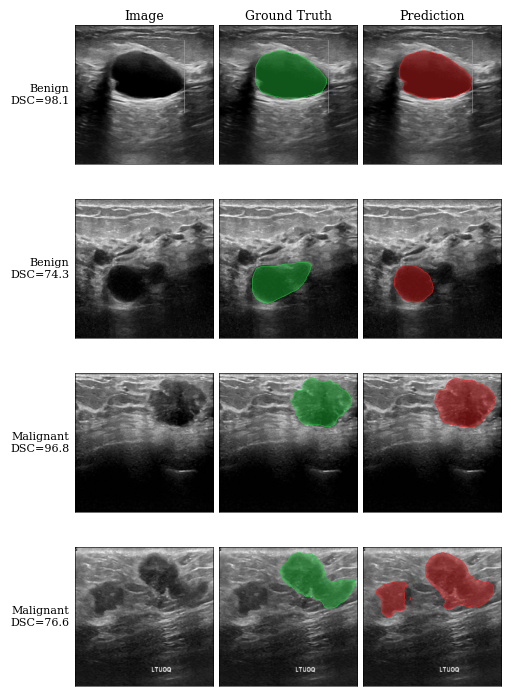

Kaydedildi: /content/drive/MyDrive/BUSI_Project/outputs/fig_qualitative_panel.pdf
Seçilen vakalar:
  benign    benign_benign_330.png        DSC= 98.1
  benign    benign_benign_41.png         DSC= 74.3
  malignant malignant_malignant_87.png   DSC= 96.8
  malignant malignant_malignant_140.png  DSC= 76.6


In [ ]:
# =====================================================================
#  ASYU 2026 — Nitel Segmentasyon Paneli (Colab hücresi)
#  Satırlar: benign & malignant × (Best / Median / Worst)
#  Sütunlar: Image | Ground Truth | Prediction   (Şekil 3.2 tarzı)
#  Pipeline notebook ile BİREBİR: UNet++/eff-b4, 5-fold ensemble + TTA, eşik 0.5
# =====================================================================
import os, glob
import numpy as np, pandas as pd, cv2
import matplotlib as mpl, matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 0) AYARLAR  (yolları Colab'a göre düzenle)
# ---------------------------------------------------------------------
BASE = "/content/drive/MyDrive/BUSI_Project"
PROC = f"{BASE}/processed"; CKPT = f"{BASE}/checkpoints"
SPL  = f"{BASE}/splits";    OUT  = f"{BASE}/outputs"

IMG_SIZE = globals().get("IMG_SIZE", 256)
LANG     = "EN"                      # "EN" veya "TR"

# Bindirme renkleri (RGB 0-1) — GT yeşil, Tahmin kırmızı
GT_COLOR, PRED_COLOR, ALPHA = (0.15, 0.80, 0.25), (0.92, 0.15, 0.15), 0.42

TXT = {
    "EN": dict(img="Image", gt="Ground Truth", pred="Prediction",
               best="Best", median="Median", worst="Worst",
               cls={"benign": "Benign", "malignant": "Malignant"}),
    "TR": dict(img="Görüntü", gt="Gerçek Maske", pred="Tahmin",
               best="En İyi", median="Medyan", worst="En Kötü",
               cls={"benign": "Benign", "malignant": "Malignant"}),
}[LANG]

mpl.rcParams.update({"font.family": "serif",
                     "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
                     "pdf.fonttype": 42, "ps.fonttype": 42})

# ---------------------------------------------------------------------
# 1) MODEL — bellekte yoksa checkpoint'leri yükle (notebook ile aynı)
# ---------------------------------------------------------------------
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
ENCODER = globals().get("ENCODER", "efficientnet-b4")

if "val_tfm" not in globals():
    val_tfm = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
                         A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

if "ensemble_tta" not in globals() or "models" not in globals():
    def build_model(pretrained=False):
        return smp.UnetPlusPlus(
            encoder_name=ENCODER,
            encoder_weights="imagenet" if pretrained else None,
            in_channels=3, classes=1, activation=None,
            decoder_channels=(256, 128, 64, 32, 16),
            decoder_attention_type="scse").to(DEVICE)

    models = []
    for c in sorted(glob.glob(f"{CKPT}/fold*_best.pth")):   # unet_fold*'u almaz
        m = build_model(False)
        m.load_state_dict(torch.load(c, map_location=DEVICE)); m.eval()
        models.append(m)
    print(f"Yüklenen checkpoint sayısı: {len(models)}")
    assert len(models) == 5, "5 fold beklendi; checkpoint yolunu kontrol et."

    @torch.no_grad()
    def ensemble_tta(x):
        x = x.unsqueeze(0).to(DEVICE); preds = []
        for m in models:
            for flips in [[], [2], [3], [2, 3]]:
                xi = x.clone()
                for fp in flips: xi = torch.flip(xi, [fp])
                p = torch.sigmoid(m(xi))
                for fp in flips: p = torch.flip(p, [fp])
                preds.append(p.cpu())
        return torch.stack(preds).mean(0).squeeze(0)

# ---------------------------------------------------------------------
# 2) VAKA SEÇİMİ — her sınıftan Best / Median / Worst (DSC'ye göre)
# ---------------------------------------------------------------------
met = pd.read_csv(f"{OUT}/dl_test_metrics.csv")
met["dice_pct"] = met["dice"] * 100 if met["dice"].max() <= 1.5 else met["dice"]

TARGET_MID = 75.0   # "orta" örnek için hedef DSC (~70'ler)

selected = []   # (cls, file, dice_pct) — her sınıftan: en iyi + hedefe en yakın
for cls in ["benign", "malignant"]:
    sub = met[met["cls"] == cls].reset_index(drop=True)
    best_idx = sub["dice_pct"].idxmax()
    # hedefe en yakın (en iyi vakayla aynı olmasın)
    cand = sub.drop(index=best_idx)
    mid_idx = (cand["dice_pct"] - TARGET_MID).abs().idxmin()
    for idx in [best_idx, mid_idx]:
        r = sub.loc[idx]
        selected.append((cls, r["file"], r["dice_pct"]))

# ---------------------------------------------------------------------
# 3) YARDIMCILAR — yükle, tahmin et, bindirme üret
# ---------------------------------------------------------------------
def load_pair(fname):
    img = cv2.cvtColor(cv2.imread(f"{PROC}/images/{fname}"), cv2.COLOR_BGR2RGB)
    gt  = cv2.imread(f"{PROC}/masks/{fname}", cv2.IMREAD_GRAYSCALE)
    gray = cv2.resize(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), (IMG_SIZE, IMG_SIZE))
    gt   = (cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST) > 127).astype(np.uint8)
    return img, gray, gt

def predict(img, gt=None):
    # Tahmin için maskeye gerek yok; sadece görüntüyü dönüştür (256'ya Resize burada olur)
    x = val_tfm(image=img)["image"].float()
    prob = ensemble_tta(x).squeeze().cpu().numpy()
    return (prob > 0.5).astype(np.uint8)

def overlay(gray, mask, color):
    rgb = np.dstack([gray] * 3).astype(np.float32) / 255.0
    m = mask.astype(bool)
    rgb[m] = (1 - ALPHA) * rgb[m] + ALPHA * np.array(color)
    rgb8 = (rgb * 255).astype(np.uint8)
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(rgb8, cnts, -1, tuple(int(c * 255) for c in color), 1)
    return rgb8

# ---------------------------------------------------------------------
# 4) PANELİ ÇİZ  (6 satır × 3 sütun)
# ---------------------------------------------------------------------
n = len(selected)
fig, axes = plt.subplots(n, 3, figsize=(5.4, 1.78 * n))
if n == 1: axes = axes[None, :]

for row, (cls, fname, dsc) in enumerate(selected):
    img, gray, gt = load_pair(fname)
    pred = predict(img, gt)
    panels = [gray, overlay(gray, gt, GT_COLOR), overlay(gray, pred, PRED_COLOR)]
    for col, im in enumerate(panels):
        ax = axes[row][col]
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_linewidth(0.4)
        if row == 0:
            ax.set_title([TXT["img"], TXT["gt"], TXT["pred"]][col], fontsize=9, pad=4)
    axes[row][0].set_ylabel(f"{TXT['cls'][cls]}\nDSC={dsc:.1f}",
                            rotation=0, ha="right", va="center", fontsize=8)

fig.subplots_adjust(wspace=0.04, hspace=0.08, left=0.20, right=0.99, top=0.97, bottom=0.01)
pdf = f"{OUT}/fig_qualitative_panel.pdf"
fig.savefig(pdf, dpi=220, bbox_inches="tight")
fig.savefig(pdf.replace(".pdf", ".png"), dpi=220, bbox_inches="tight")
plt.show()
print("Kaydedildi:", pdf)
print("Seçilen vakalar:")
for cls, f, d in selected:
    print(f"  {cls:9s} {f:28s} DSC={d:5.1f}")

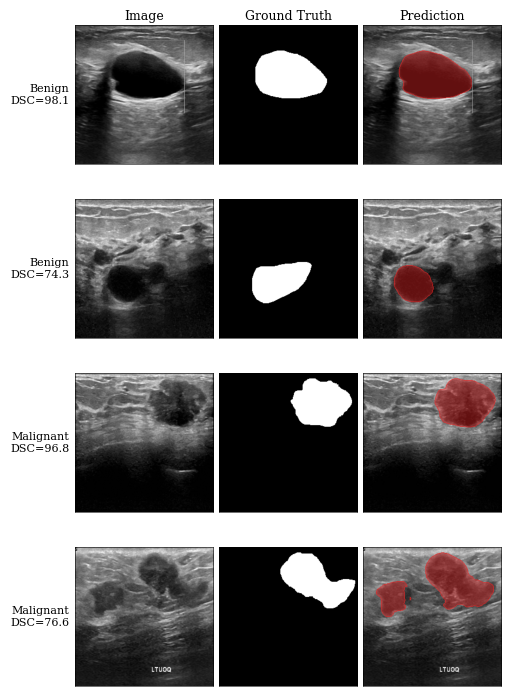

Kaydedildi: /content/drive/MyDrive/BUSI_Project/outputs/fig_qualitative_panel_gt.pdf
Seçilen vakalar:
  benign    benign_benign_330.png        DSC= 98.1
  benign    benign_benign_41.png         DSC= 74.3
  malignant malignant_malignant_87.png   DSC= 96.8
  malignant malignant_malignant_140.png  DSC= 76.6


In [ ]:
# =====================================================================
#  ASYU 2026 — Nitel Segmentasyon Paneli (Colab hücresi)
#  Satırlar: benign & malignant × (Best / Median / Worst)
#  Sütunlar: Image | Ground Truth | Prediction   (Şekil 3.2 tarzı)
#  Pipeline notebook ile BİREBİR: UNet++/eff-b4, 5-fold ensemble + TTA, eşik 0.5
# =====================================================================
import os, glob
import numpy as np, pandas as pd, cv2
import matplotlib as mpl, matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 0) AYARLAR  (yolları Colab'a göre düzenle)
# ---------------------------------------------------------------------
BASE = "/content/drive/MyDrive/BUSI_Project"
PROC = f"{BASE}/processed"; CKPT = f"{BASE}/checkpoints"
SPL  = f"{BASE}/splits";    OUT  = f"{BASE}/outputs"

IMG_SIZE = globals().get("IMG_SIZE", 256)
LANG     = "EN"                      # "EN" veya "TR"

# Bindirme renkleri (RGB 0-1) — GT yeşil, Tahmin kırmızı
GT_COLOR, PRED_COLOR, ALPHA = (0.15, 0.80, 0.25), (0.92, 0.15, 0.15), 0.42

TXT = {
    "EN": dict(img="Image", gt="Ground Truth", pred="Prediction",
               best="Best", median="Median", worst="Worst",
               cls={"benign": "Benign", "malignant": "Malignant"}),
    "TR": dict(img="Görüntü", gt="Gerçek Maske", pred="Tahmin",
               best="En İyi", median="Medyan", worst="En Kötü",
               cls={"benign": "Benign", "malignant": "Malignant"}),
}[LANG]

mpl.rcParams.update({"font.family": "serif",
                     "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
                     "pdf.fonttype": 42, "ps.fonttype": 42})

# ---------------------------------------------------------------------
# 1) MODEL — bellekte yoksa checkpoint'leri yükle (notebook ile aynı)
# ---------------------------------------------------------------------
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
ENCODER = globals().get("ENCODER", "efficientnet-b4")

if "val_tfm" not in globals():
    val_tfm = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
                         A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

if "ensemble_tta" not in globals() or "models" not in globals():
    def build_model(pretrained=False):
        return smp.UnetPlusPlus(
            encoder_name=ENCODER,
            encoder_weights="imagenet" if pretrained else None,
            in_channels=3, classes=1, activation=None,
            decoder_channels=(256, 128, 64, 32, 16),
            decoder_attention_type="scse").to(DEVICE)

    models = []
    for c in sorted(glob.glob(f"{CKPT}/fold*_best.pth")):   # unet_fold*'u almaz
        m = build_model(False)
        m.load_state_dict(torch.load(c, map_location=DEVICE)); m.eval()
        models.append(m)
    print(f"Yüklenen checkpoint sayısı: {len(models)}")
    assert len(models) == 5, "5 fold beklendi; checkpoint yolunu kontrol et."

    @torch.no_grad()
    def ensemble_tta(x):
        x = x.unsqueeze(0).to(DEVICE); preds = []
        for m in models:
            for flips in [[], [2], [3], [2, 3]]:
                xi = x.clone()
                for fp in flips: xi = torch.flip(xi, [fp])
                p = torch.sigmoid(m(xi))
                for fp in flips: p = torch.flip(p, [fp])
                preds.append(p.cpu())
        return torch.stack(preds).mean(0).squeeze(0)

# ---------------------------------------------------------------------
# 2) VAKA SEÇİMİ — her sınıftan Best / Median / Worst (DSC'ye göre)
# ---------------------------------------------------------------------
met = pd.read_csv(f"{OUT}/dl_test_metrics.csv")
met["dice_pct"] = met["dice"] * 100 if met["dice"].max() <= 1.5 else met["dice"]

TARGET_MID = 75.0   # "orta" örnek için hedef DSC (~70'ler)

selected = []   # (cls, file, dice_pct) — her sınıftan: en iyi + hedefe en yakın
for cls in ["benign", "malignant"]:
    sub = met[met["cls"] == cls].reset_index(drop=True)
    best_idx = sub["dice_pct"].idxmax()
    # hedefe en yakın (en iyi vakayla aynı olmasın)
    cand = sub.drop(index=best_idx)
    mid_idx = (cand["dice_pct"] - TARGET_MID).abs().idxmin()
    for idx in [best_idx, mid_idx]:
        r = sub.loc[idx]
        selected.append((cls, r["file"], r["dice_pct"]))

# ---------------------------------------------------------------------
# 3) YARDIMCILAR — yükle, tahmin et, bindirme üret
# ---------------------------------------------------------------------
def load_pair(fname):
    img = cv2.cvtColor(cv2.imread(f"{PROC}/images/{fname}"), cv2.COLOR_BGR2RGB)
    gt  = cv2.imread(f"{PROC}/masks/{fname}", cv2.IMREAD_GRAYSCALE)
    gray = cv2.resize(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), (IMG_SIZE, IMG_SIZE))
    gt   = (cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST) > 127).astype(np.uint8)
    return img, gray, gt

def predict(img, gt=None):
    # Tahmin için maskeye gerek yok; sadece görüntüyü dönüştür (256'ya Resize burada olur)
    x = val_tfm(image=img)["image"].float()
    prob = ensemble_tta(x).squeeze().cpu().numpy()
    return (prob > 0.5).astype(np.uint8)

def overlay(gray, mask, color):
    rgb = np.dstack([gray] * 3).astype(np.float32) / 255.0
    m = mask.astype(bool)
    rgb[m] = (1 - ALPHA) * rgb[m] + ALPHA * np.array(color)
    rgb8 = (rgb * 255).astype(np.uint8)
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(rgb8, cnts, -1, tuple(int(c * 255) for c in color), 1)
    return rgb8

# ---------------------------------------------------------------------
# 4) PANELİ ÇİZ  (6 satır × 3 sütun)
# ---------------------------------------------------------------------
n = len(selected)
fig, axes = plt.subplots(n, 3, figsize=(5.4, 1.78 * n))
if n == 1: axes = axes[None, :]

for row, (cls, fname, dsc) in enumerate(selected):
    img, gray, gt = load_pair(fname)
    pred = predict(img, gt)
    gt_mask = (gt * 255).astype(np.uint8)              # düz GT maskesi (siyah/beyaz)
    panels = [gray, gt_mask, overlay(gray, pred, PRED_COLOR)]
    for col, im in enumerate(panels):
        ax = axes[row][col]
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_linewidth(0.4)
        if row == 0:
            ax.set_title([TXT["img"], TXT["gt"], TXT["pred"]][col], fontsize=9, pad=4)
    axes[row][0].set_ylabel(f"{TXT['cls'][cls]}\nDSC={dsc:.1f}",
                            rotation=0, ha="right", va="center", fontsize=8)

fig.subplots_adjust(wspace=0.04, hspace=0.08, left=0.20, right=0.99, top=0.97, bottom=0.01)
pdf = f"{OUT}/fig_qualitative_panel_gt.pdf"
fig.savefig(pdf, dpi=220, bbox_inches="tight")
fig.savefig(pdf.replace(".pdf", ".png"), dpi=220, bbox_inches="tight")
plt.show()
print("Kaydedildi:", pdf)
print("Seçilen vakalar:")
for cls, f, d in selected:
    print(f"  {cls:9s} {f:28s} DSC={d:5.1f}")

## Bölüm 11 — Perfomans Analizi - Maaliyet Hesabı.



In [ ]:
!pip install -q thop segmentation-models-pytorch

import torch
import time
import segmentation_models_pytorch as smp
from thop import profile

ENCODER = "efficientnet-b4"
IMG_SIZE = 256
model = smp.UnetPlusPlus(
    encoder_name=ENCODER,
    encoder_weights=None,
    in_channels=3,
    classes=1
)
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

macs, params = profile(model, inputs=(dummy_input, ), verbose=False)
flops = macs * 2
gflops = flops / 1e9

print("\n--- MODEL BILGILERI ---")
print(f"Toplam Parametre: {params / 1e6:.2f} Milyon")
print(f"Islem Yuku: {gflops:.2f} GFLOPs")

if device == 'cuda':
    for _ in range(10):
        _ = model(dummy_input)

    times = []
    with torch.no_grad():
        for _ in range(100):
            start = time.time()
            _ = model(dummy_input)
            torch.cuda.synchronize()
            times.append(time.time() - start)

    avg_time_ms = np.mean(times) * 1000
    ensemble_time_ms = avg_time_ms * 20
    fps = 1000 / ensemble_time_ms

    print(f"\n--- HIZ VERILERI ({torch.cuda.get_device_name(0)}) ---")
    print(f"Tek Model Cikarim Suresi: {avg_time_ms:.2f} ms")
    print(f"Tam Topluluk Cikarim Suresi: {ensemble_time_ms:.2f} ms")
    print(f"Sistem Hizi: {fps:.2f} FPS")
else:
    print("\nUYARI: Hiz testi icin GPU (cuda) bulunamadi.")


--- MODEL BILGILERI ---
Toplam Parametre: 3.39 Milyon
Islem Yuku: 15.84 GFLOPs

--- HIZ VERILERI (Tesla T4) ---
Tek Model Cikarim Suresi: 61.39 ms
Tam Topluluk Cikarim Suresi: 1227.76 ms
Sistem Hizi: 0.81 FPS
